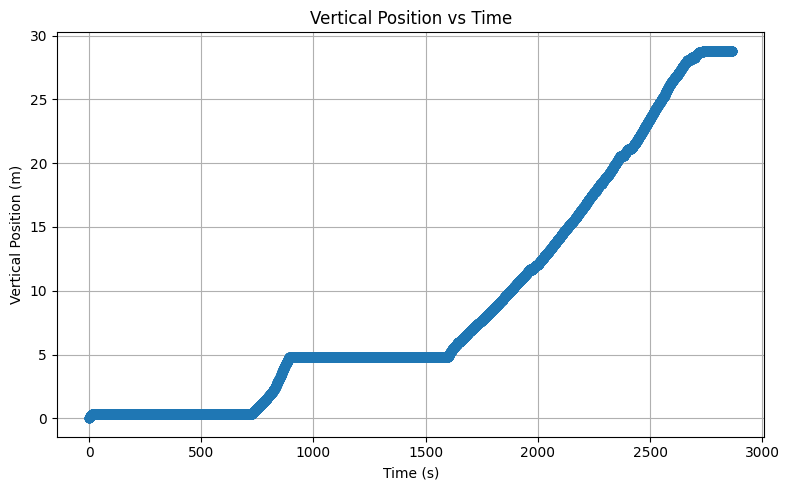

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Cargar datos ---
file_path = r"C:\Users\Mariana\Documents\freshwater_lens\data\raw\raw_lrs70\LRS70_D_YSI_20230822.csv"
df = pd.read_csv(file_path)

# --- Asegurar nombres de columnas ---
time_col = "Time (HH:mm:ss)"
fract_col = "Time (Fract. Sec)"
vp_col = "Vertical Position m"

# --- Convertir HH:mm:ss a segundos ---
time_seconds = pd.to_timedelta(df[time_col]).dt.total_seconds()

# --- Sumar fracción de segundo ---
time_total = time_seconds + df[fract_col]

# --- Convertir a tiempo relativo (inicio = 0) ---
time_relative = time_total - time_total.iloc[0]

# --- Guardar en el dataframe ---
df["time_sec"] = time_relative

# --- Graficar ---
plt.figure(figsize=(8, 5))
plt.plot(df["time_sec"], df[vp_col], marker='o', linestyle='-')

plt.xlabel("Time (s)")
plt.ylabel("Vertical Position (m)")
plt.title("Vertical Position vs Time")
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import plotly.graph_objects as go

# --- Cargar datos ---
#file_path = r"C:\Users\Mariana\Documents\freshwater_lens\data\raw\raw_lrs70\LRS70_D_YSI_20230822.csv"
file_path = r"C:\Users\Mariana\Documents\freshwater_lens\data\raw\raw_lrs70\LRS70_D_YSI_R_20250226.csv"
df = pd.read_csv(file_path)

# --- Columnas ---
time_col = "Time (HH:mm:ss)"
fract_col = "Time (Fract. Sec)"
vp_col = "Vertical Position m"

# --- Convertir HH:mm:ss a segundos ---
time_seconds = pd.to_timedelta(df[time_col]).dt.total_seconds()

# --- Sumar fracción de segundo ---
time_total = time_seconds + df[fract_col]

# --- Convertir a tiempo relativo (inicio = 0) ---
df["time_sec"] = time_total - time_total.iloc[0]

# --- Crear figura ---
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["time_sec"],
        y=df[vp_col],
        mode="lines+markers",  # línea + puntos
        name="Vertical Position",
        marker=dict(size=4),
        line=dict(width=2)
    )
)

# --- Layout ---
fig.update_layout(
    title="LRS70_D_YSI_R_20250226.csv",
    xaxis_title="Time (s)",
    yaxis_title="Vertical Position (m)",
    template="plotly_white"
)

# (Opcional) invertir eje Y si es perfil vertical
# fig.update_yaxes(autorange="reversed")

# --- Mostrar ---
fig.show()